# Experiments over CHILD dataset

## Prepare packages and library

In [1]:
import bnlearn as bn
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, UtilityAlignedTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo
from utils import *
from xgboost import XGBClassifier

/home/alexis/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alexis/.local/lib/python3.10/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def evaluate_models(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) 
    accuracy = accuracy_score(y_test, y_pred)
    logloss = log_loss(y_test, y_prob)
    
    if len(np.unique(y_test)) > 2:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    else:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        
    return accuracy, -logloss, roc_auc

def model_performance(model, X_test, y_test):
    accuracy, logloss, roc_auc = evaluate_models(model, X_test, y_test)
    return {
        "accuracy": accuracy,
        "logloss": -logloss,
        "roc_auc": roc_auc
    }

In [3]:
DAG = bn.import_DAG("child.bif")
df = bn.sampling(DAG, n=10000)
rvoto = list(range(2, 4))
df['RVOTO'] = df['Disease'].apply(lambda x: 1 if x in rvoto else 0)
valid_features = [
    'Age', 
    'BirthAsphyxia', 
    'Sick', 
    'GruntingReport', 
    'RUQO2', 
    'LowerBodyO2', 
    'HypoxiaInO2', 
    'XrayReport', 
    'LVHreport', 
    'CO2Report',
    'RVOTO'
]
df_ml = df[valid_features].copy()
df_full_ml = df.copy().drop(columns=['Disease'])

[bnlearn] >Import <child.bif>
[bnlearn] >Loading bif file <child.bif>
[bnlearn] >[CPD > Validate] >[Node Age] >Table Error: Does not sum to 1 but is [[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]]
[bnlearn] >[CPD > Validate] >[Node BirthAsphyxia] >OK
[bnlearn] >[CPD > Validate] >[Node CO2] >OK
[bnlearn] >[CPD > Validate] >[Node CO2Report] >OK
[bnlearn] >[CPD > Validate] >[Node CardiacMixing] >OK
[bnlearn] >[CPD > Validate] >[Node ChestXray] >Table Error: Does not sum to 1 but is [[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]]
[bnlearn] >[CPD > Validate] >[Node Disease] >OK
[bnlearn] >[CPD > Validate] >[Node DuctFlow] >OK
[bnlearn] >[CPD > Validate] >[Node Grunting] >OK
[bnlearn] >[CPD > Validate] >[Node GruntingReport] >OK
[bnlearn] >[CPD > Validate] >[Node HypDistrib] >OK
[bnlearn] >[CPD > Validate] >[Node HypoxiaInO2] >Table Error: Does not sum to 1 but is [[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]]
[bnlearn] >[CPD > Validate] >[Node LVH] >OK
[bnlearn] >[CPD > Validate] >[Node

In [4]:
df_ml

,Age,BirthAsphyxia,Sick,GruntingReport,RUQO2,LowerBodyO2,HypoxiaInO2,XrayReport,LVHreport,CO2Report,RVOTO
0,0,1,0,0,2,1,1,3,1,1,1
1,0,1,1,1,0,1,2,2,1,0,0
2,2,1,1,1,1,0,2,1,1,0,0
3,0,1,1,1,1,1,1,1,1,0,1
4,2,1,1,1,1,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,1,1,2,1,1,1,0,1
9996,0,1,0,1,1,2,2,2,1,0,0
9997,1,1,1,0,0,2,0,4,1,1,0
9998,1,1,1,1,0,0,2,2,1,0,0


In [5]:
df_full_ml

,DuctFlow,HypDistrib,CardiacMixing,HypoxiaInO2,LungParench,CO2,ChestXray,LungFlow,Grunting,Sick,LVH,LVHreport,LowerBodyO2,RUQO2,CO2Report,XrayReport,BirthAsphyxia,GruntingReport,Age,RVOTO
0,0,0,2,1,0,0,3,1,1,0,1,1,1,2,1,3,1,0,0,1
1,1,0,3,2,0,0,2,2,1,1,1,1,1,0,0,2,1,1,0,0
2,1,0,3,2,0,0,2,2,1,1,1,1,0,1,0,1,1,1,2,0
3,1,0,2,1,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,1
4,0,0,2,1,0,0,0,1,1,1,1,1,1,1,0,0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,1,1,0,0,1,1,1,1,1,1,2,1,0,1,1,1,1,1
9996,1,0,3,2,0,0,2,2,1,0,1,1,2,1,0,2,1,1,0,0
9997,2,0,2,0,2,2,4,1,0,1,1,1,2,0,1,4,1,0,1,0
9998,1,0,3,2,0,0,2,2,1,1,1,1,0,0,0,2,1,1,1,0


In [6]:
print(df_ml['RVOTO'].value_counts())
print(df_ml['RVOTO'].value_counts(normalize=True))

RVOTO
1    5222
0    4778
Name: count, dtype: int64
RVOTO
1    0.5222
0    0.4778
Name: proportion, dtype: float64


In [7]:
X_full = df_full_ml.drop(columns=["RVOTO"])
y_full = df_full_ml["RVOTO"]

full_features = X_full.columns.to_list()
X_train_full, X_rest_full, y_train_full, y_rest_full = train_test_split(X_full, y_full, test_size=0.3, random_state=RANDOM_SEED)
X_val_full, X_test_full, y_val_full, y_test_full = train_test_split(X_rest_full, y_rest_full, test_size=0.5, random_state=RANDOM_SEED)


X_train_full = X_train_full.reset_index(drop=True)
X_val_full = X_val_full.reset_index(drop=True)
X_test_full = X_test_full.reset_index(drop=True)
y_train_full = y_train_full.reset_index(drop=True)
y_val_full = y_val_full.reset_index(drop=True)
y_test_full = y_test_full.reset_index(drop=True)

full_class_names = [str(c) for c in sorted(y_full.unique())]

full_model = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', n_estimators=5000, early_stopping_rounds=100)
full_model.fit(X_train_full, y_train_full, eval_set=[(X_val_full, y_val_full)], verbose=False)
model_performance(full_model, X_test_full, y_test_full)

{'accuracy': 0.9573333333333334,
 'logloss': 0.11328899998946851,
 'roc_auc': 0.9923772653472777}

In [8]:
X = df_ml.drop(columns=["RVOTO"])
y = df_ml["RVOTO"]

features = X.columns.to_list()
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=RANDOM_SEED)


X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

class_names = [str(c) for c in sorted(y.unique())]

model = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', n_estimators=5000, early_stopping_rounds=100)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
model_performance(model, X_test, y_test)

{'accuracy': 0.7806666666666666,
 'logloss': 0.4632914133810209,
 'roc_auc': 0.8620180996601646}

## Sensitivity over utility matrix

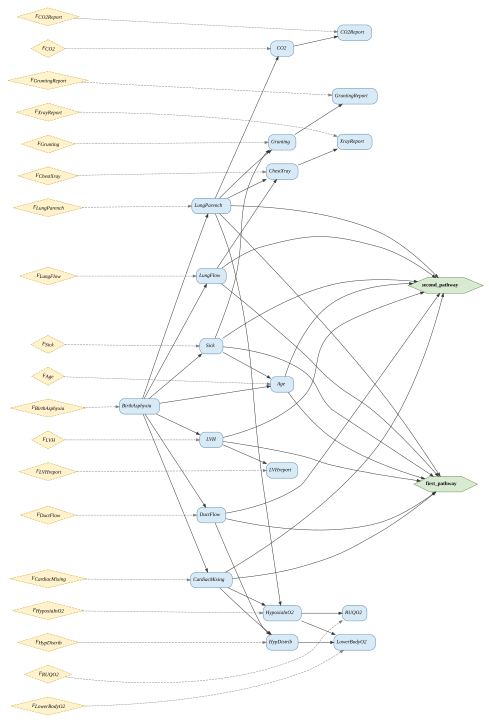

In [9]:
rq1_actions = [
    "first_pathway",
    "second_pathway"
]

rq1_causal = CausalDAG(features=full_features, actions=rq1_actions)

rq1_causal.add_causal_edge("BirthAsphyxia", "Age")
rq1_causal.add_causal_edge("BirthAsphyxia", "Sick")
rq1_causal.add_causal_edge("BirthAsphyxia", "DuctFlow")
rq1_causal.add_causal_edge("BirthAsphyxia", "CardiacMixing")
rq1_causal.add_causal_edge("BirthAsphyxia", "LungParench")
rq1_causal.add_causal_edge("BirthAsphyxia", "LungFlow")
rq1_causal.add_causal_edge("BirthAsphyxia", "LVH")

rq1_causal.add_causal_edge("Sick", "Age")
rq1_causal.add_causal_edge("Sick", "Grunting")
rq1_causal.add_causal_edge("Sick", "first_pathway")
rq1_causal.add_causal_edge("Sick", "second_pathway")

rq1_causal.add_causal_edge("DuctFlow", "HypDistrib")
rq1_causal.add_causal_edge("DuctFlow", "first_pathway")
rq1_causal.add_causal_edge("DuctFlow", "second_pathway")

rq1_causal.add_causal_edge("CardiacMixing", "HypDistrib")
rq1_causal.add_causal_edge("CardiacMixing", "HypoxiaInO2")
rq1_causal.add_causal_edge("CardiacMixing", "first_pathway")
rq1_causal.add_causal_edge("CardiacMixing", "second_pathway")

rq1_causal.add_causal_edge("LungParench", "Grunting")
rq1_causal.add_causal_edge("LungParench", "HypoxiaInO2")
rq1_causal.add_causal_edge("LungParench", "CO2")
rq1_causal.add_causal_edge("LungParench", "ChestXray")
rq1_causal.add_causal_edge("LungParench", "first_pathway")
rq1_causal.add_causal_edge("LungParench", "second_pathway")

rq1_causal.add_causal_edge("LungFlow", "ChestXray")
rq1_causal.add_causal_edge("LungFlow", "first_pathway")
rq1_causal.add_causal_edge("LungFlow", "second_pathway")

rq1_causal.add_causal_edge("LVH", "LVHreport")
rq1_causal.add_causal_edge("LVH", "first_pathway")
rq1_causal.add_causal_edge("LVH", "second_pathway")

rq1_causal.add_causal_edge("Age", "first_pathway")
rq1_causal.add_causal_edge("Age", "second_pathway")

rq1_causal.add_causal_edge("Grunting", "GruntingReport")

rq1_causal.add_causal_edge("HypDistrib", "LowerBodyO2")

rq1_causal.add_causal_edge("HypoxiaInO2", "LowerBodyO2")
rq1_causal.add_causal_edge("HypoxiaInO2", "RUQO2")

rq1_causal.add_causal_edge("CO2", "CO2Report")

rq1_causal.add_causal_edge("ChestXray", "XrayReport")

rq1_causal.add_causal_edge("LVH", "LVHreport")

rq1_dot = rq1_causal.toDot()
rq1_graph = graphviz.Source(rq1_dot)
display(rq1_graph)

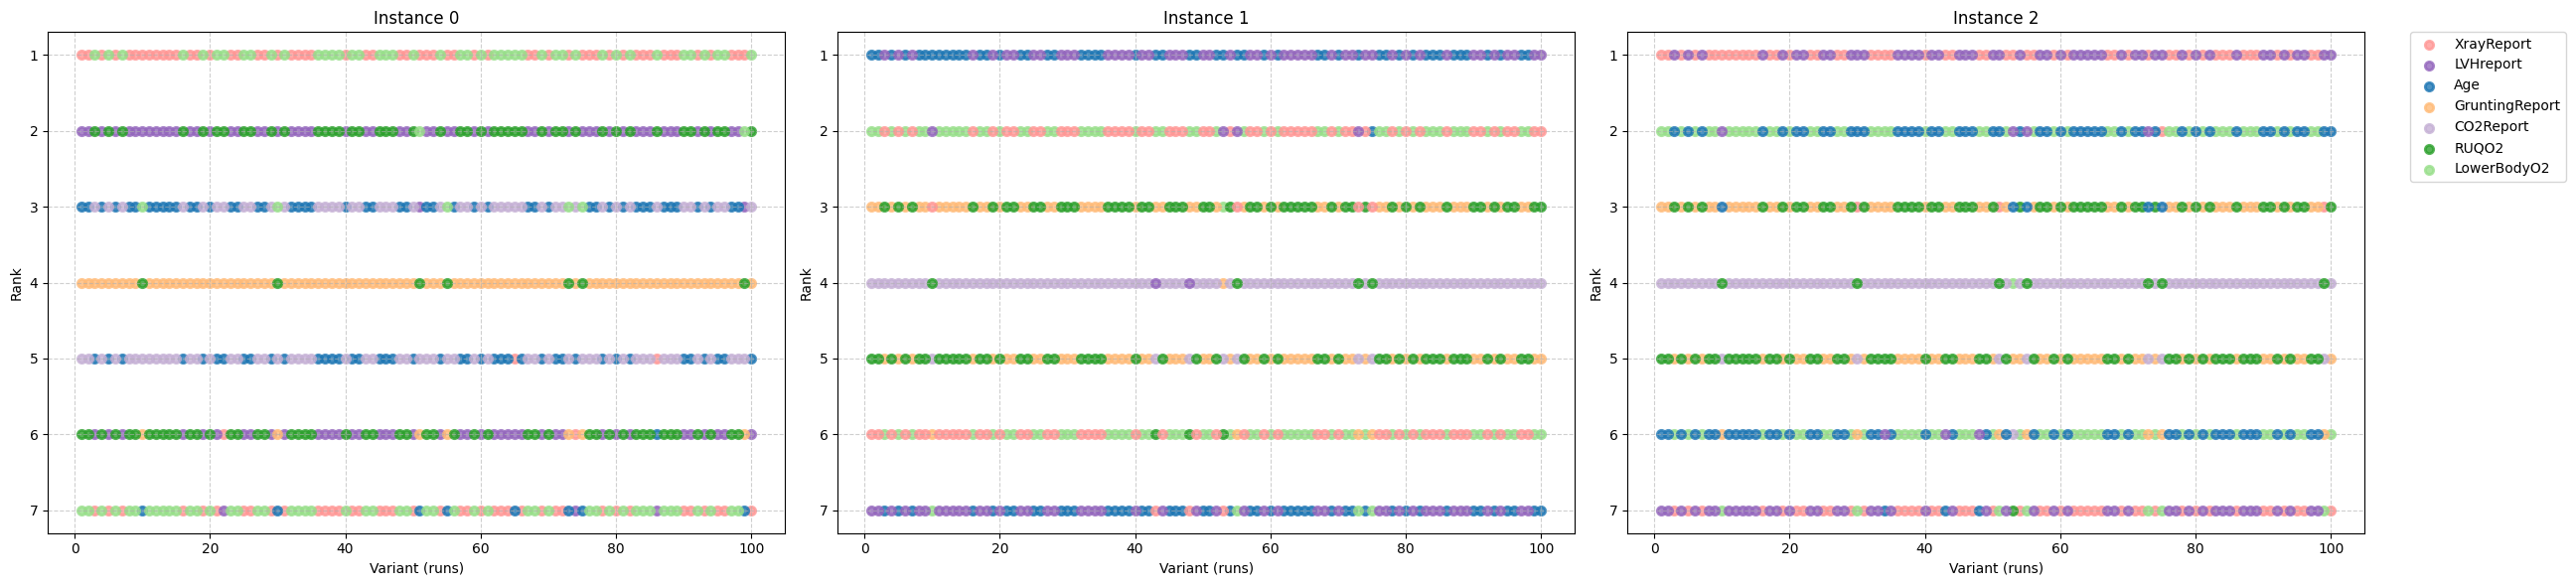

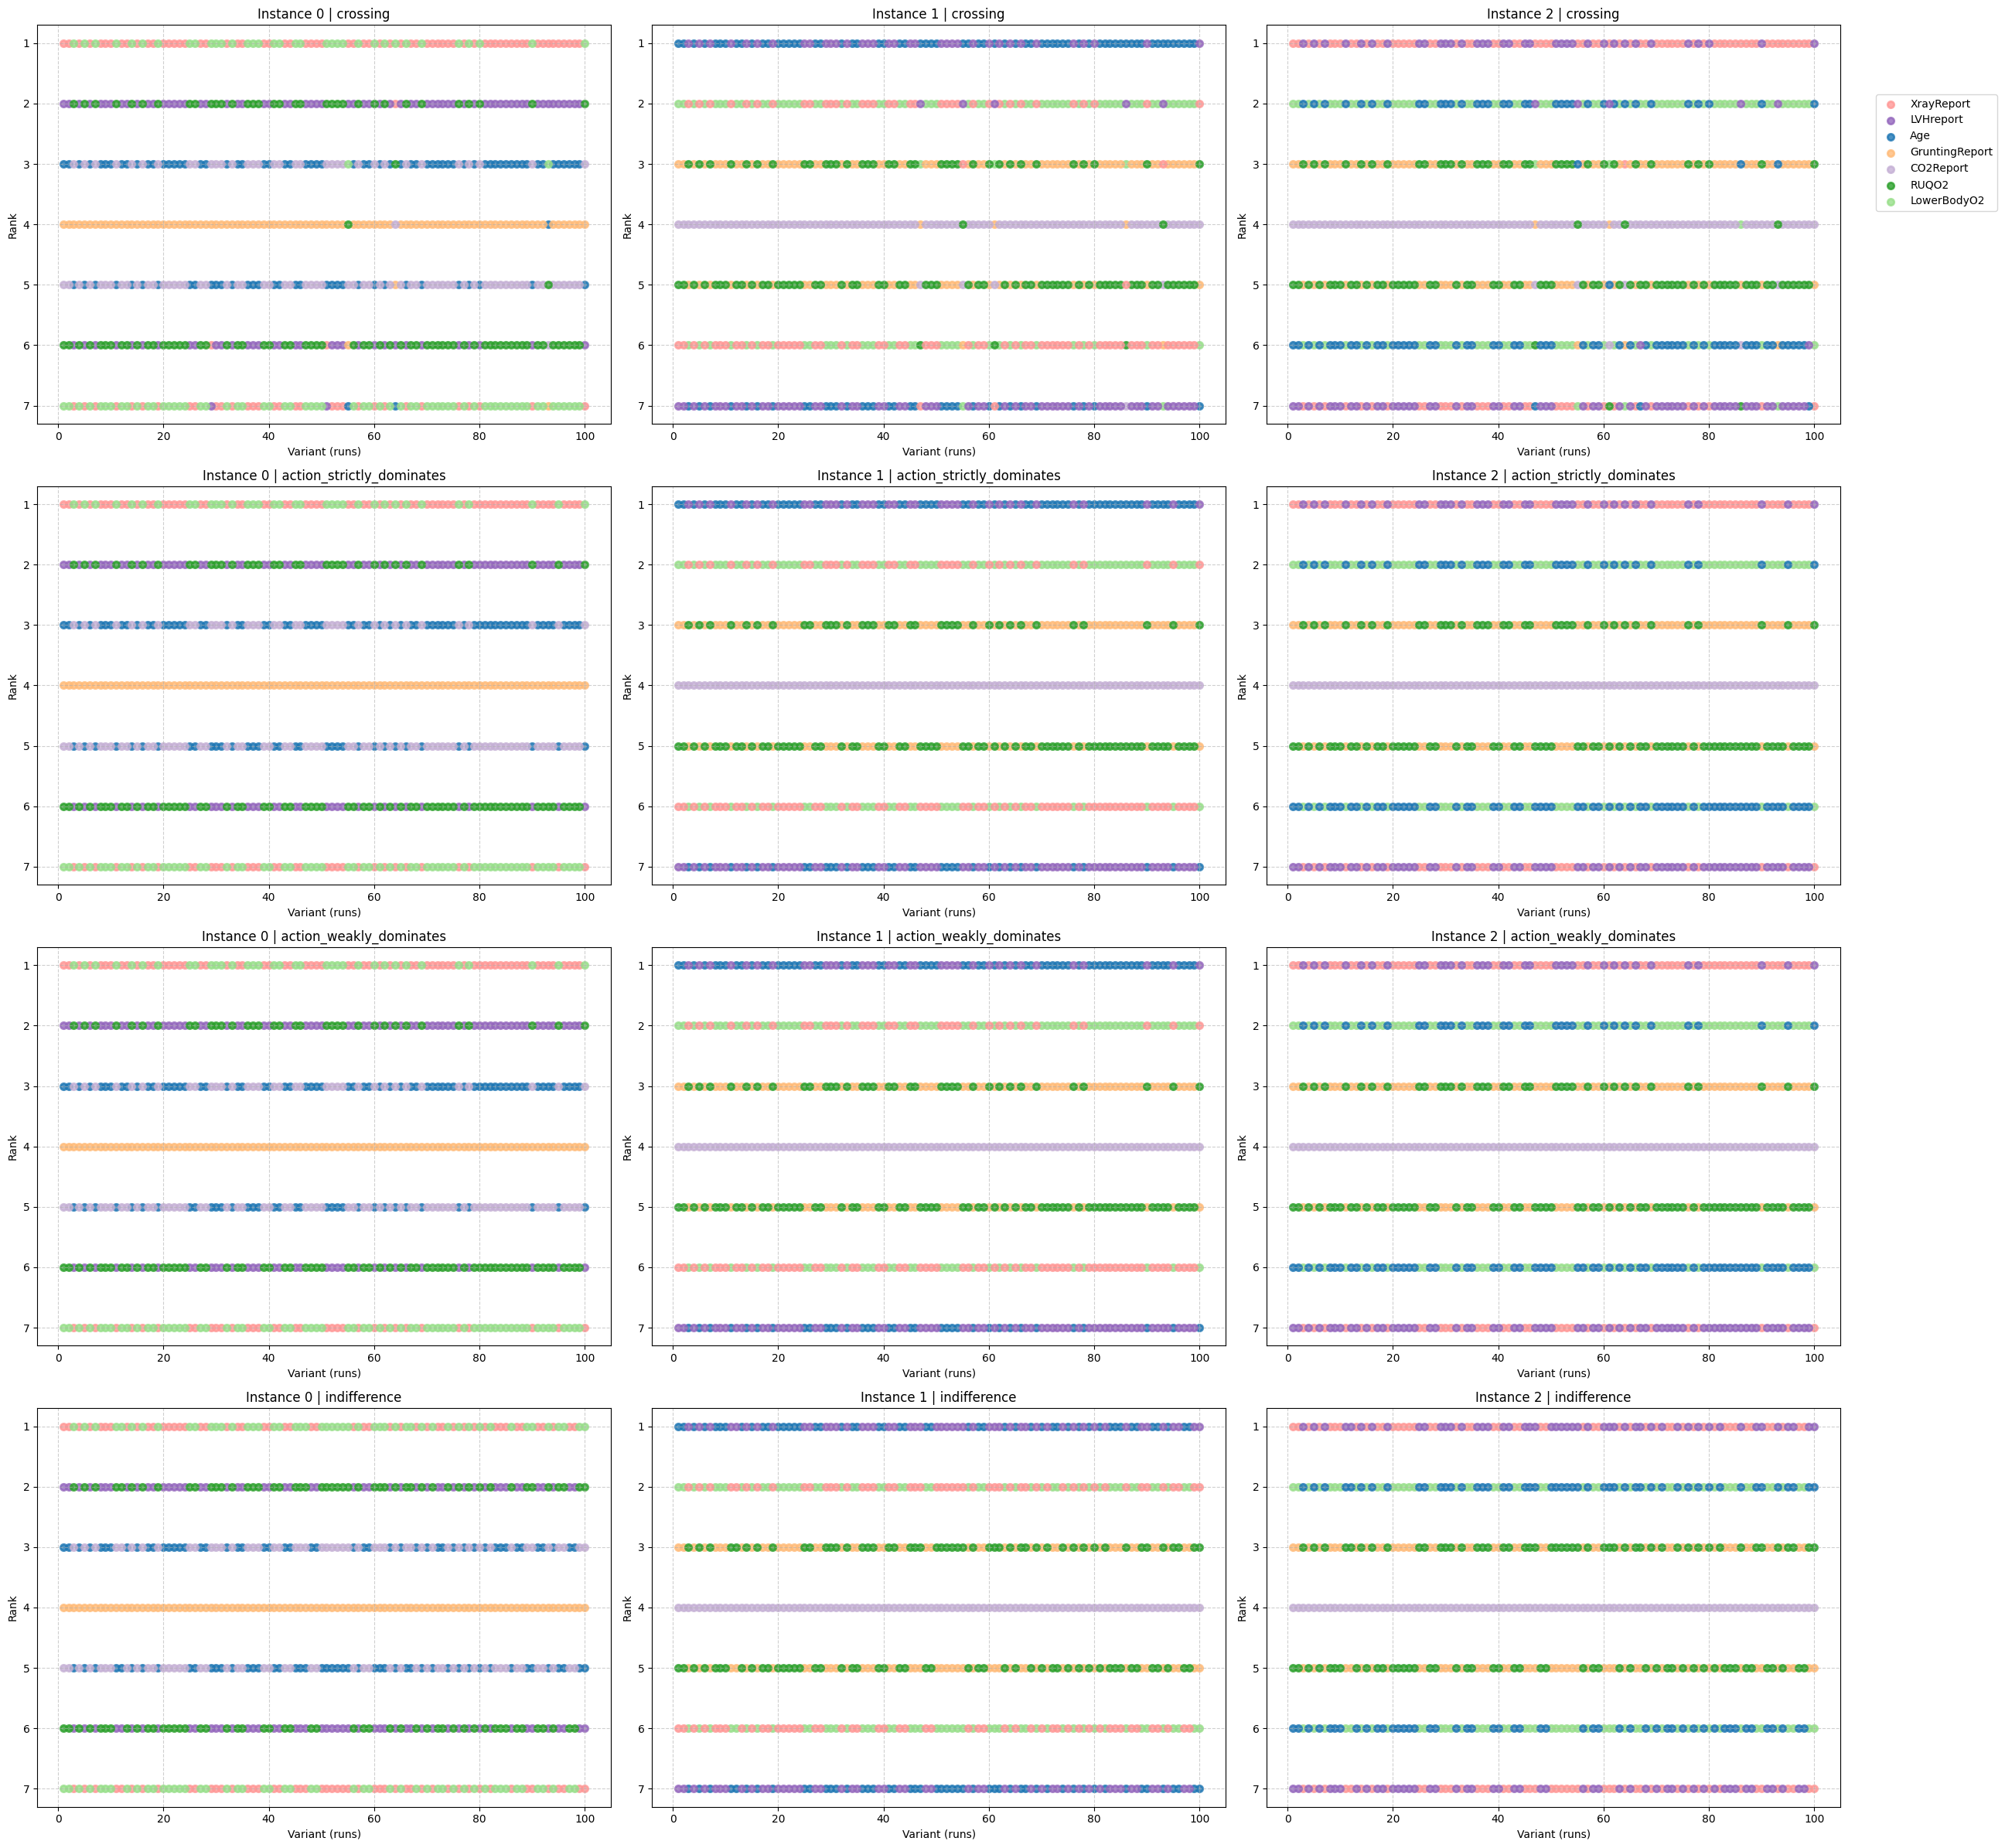

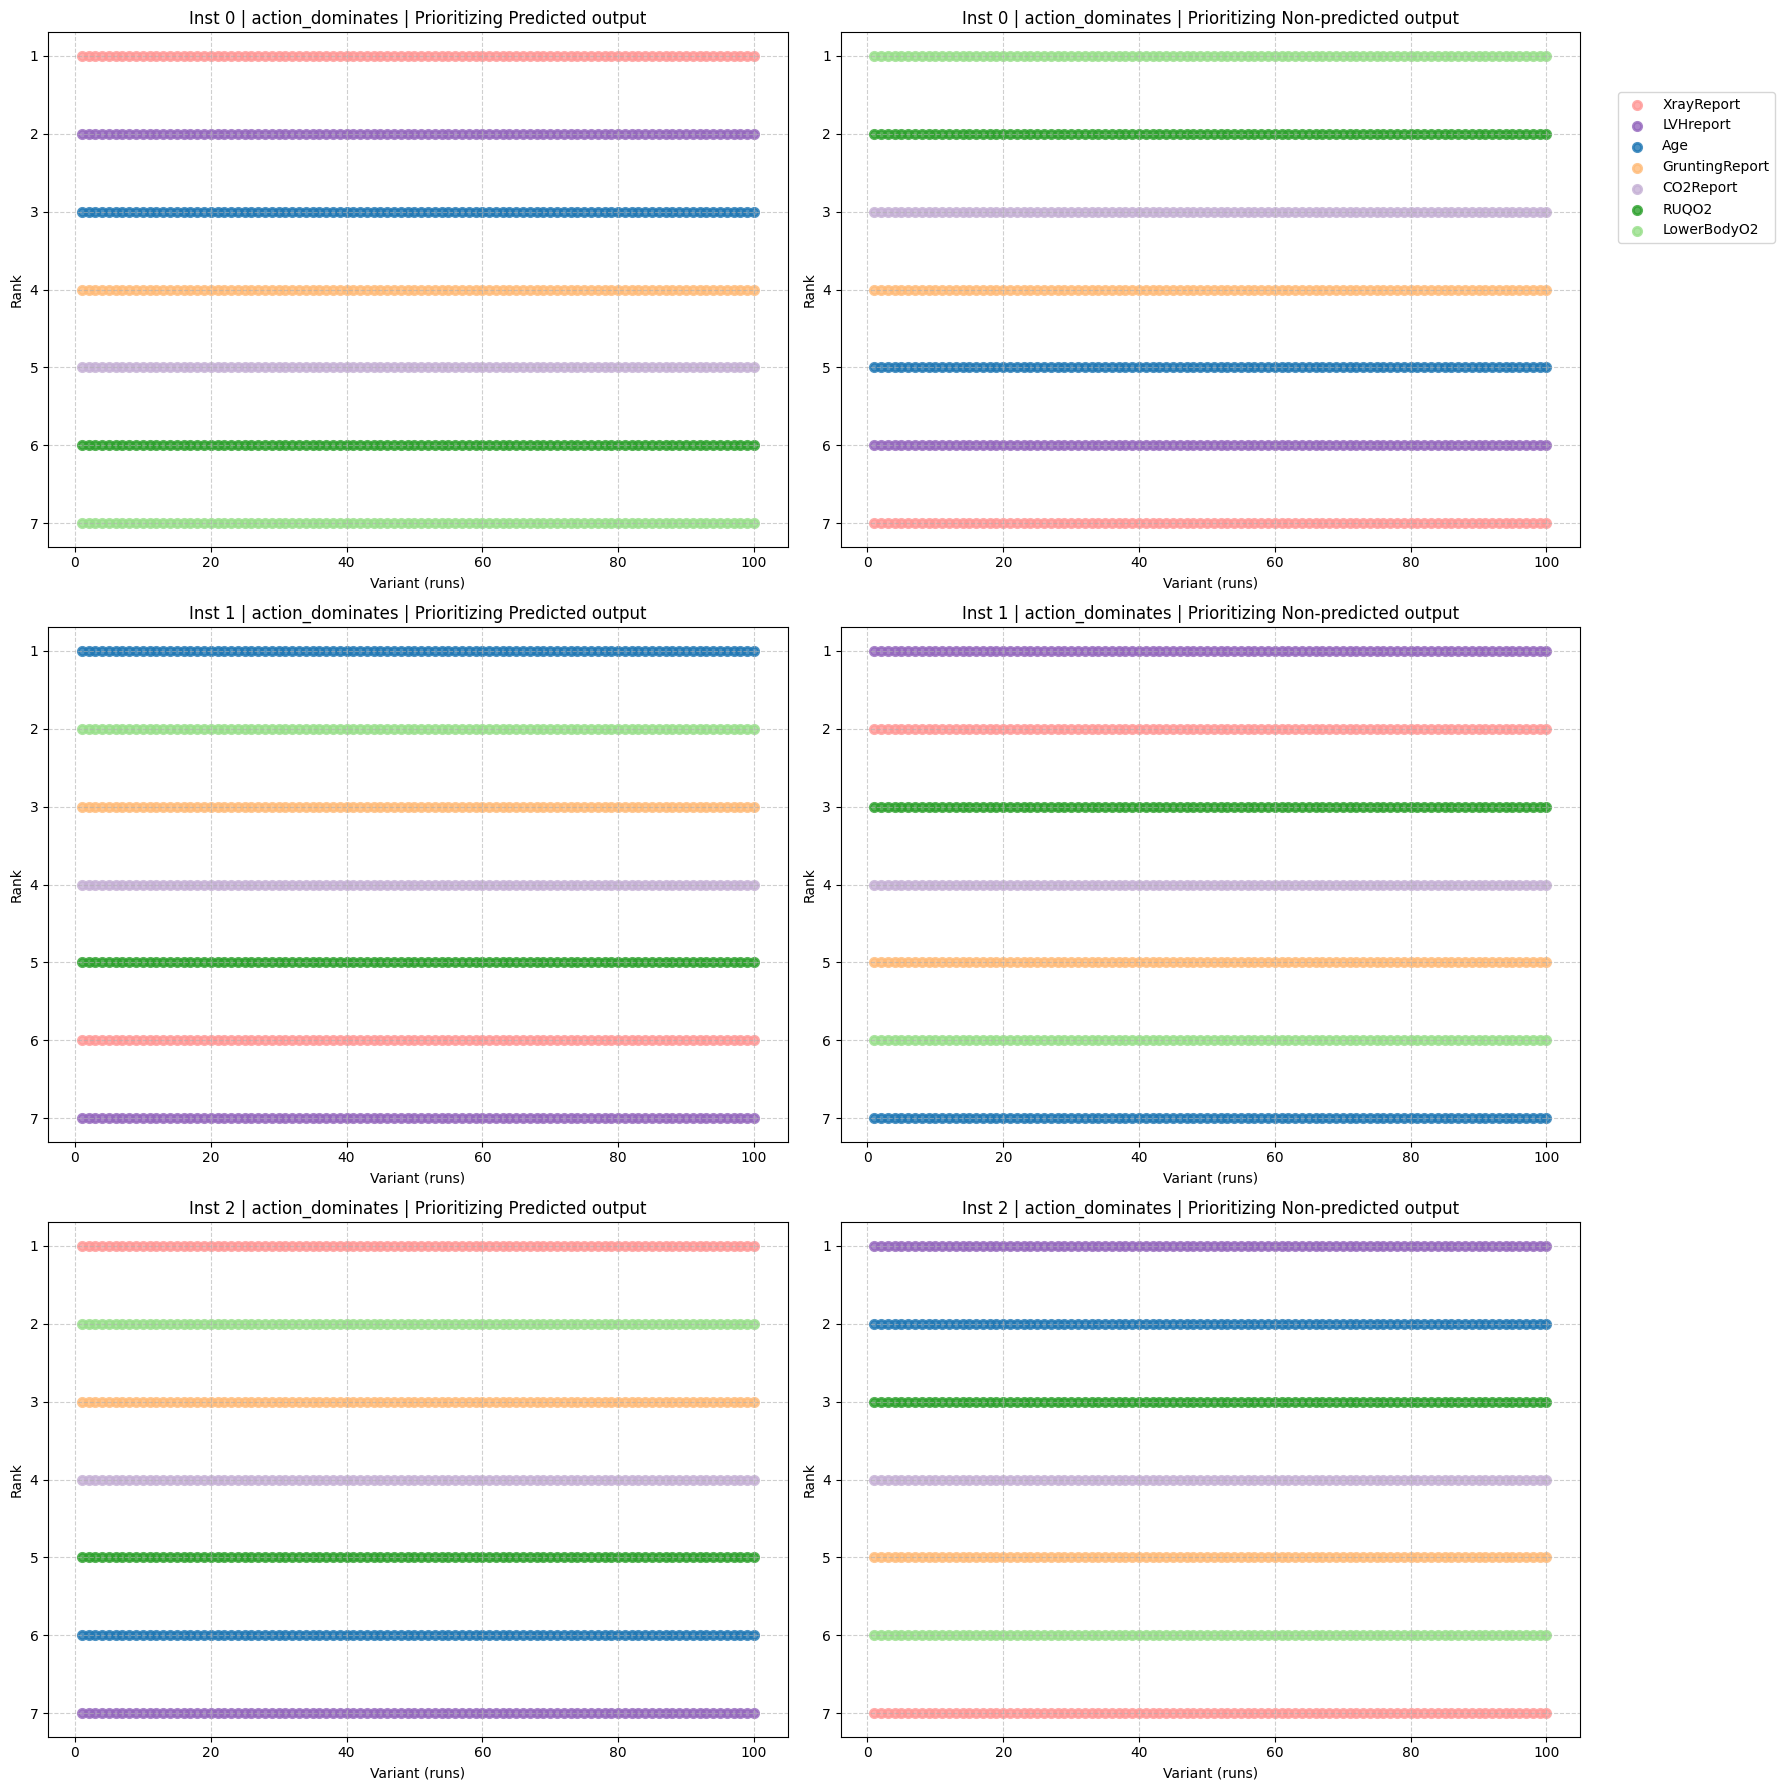

{'action_dominates': {0: {True: {'XrayReport': [1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1],
    'LVHreport': [2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,

In [11]:
explainer_tester = ExplainerTester("Sensitivity", model, features, rq1_actions, rq1_causal, X_train)
x_instances = X_test.sample(n=3, random_state=RANDOM_SEED)
explainer_tester.test_explain_instance_phase_1(x_instances, display=True)
explainer_tester.test_explain_instance_phase_2(x_instances, category=["crossing", "action_strictly_dominates", "action_weakly_dominates", "indifference"], display=True)
explainer_tester.test_explain_instance_phase_3(x_instances, category="action_dominates", display=True)

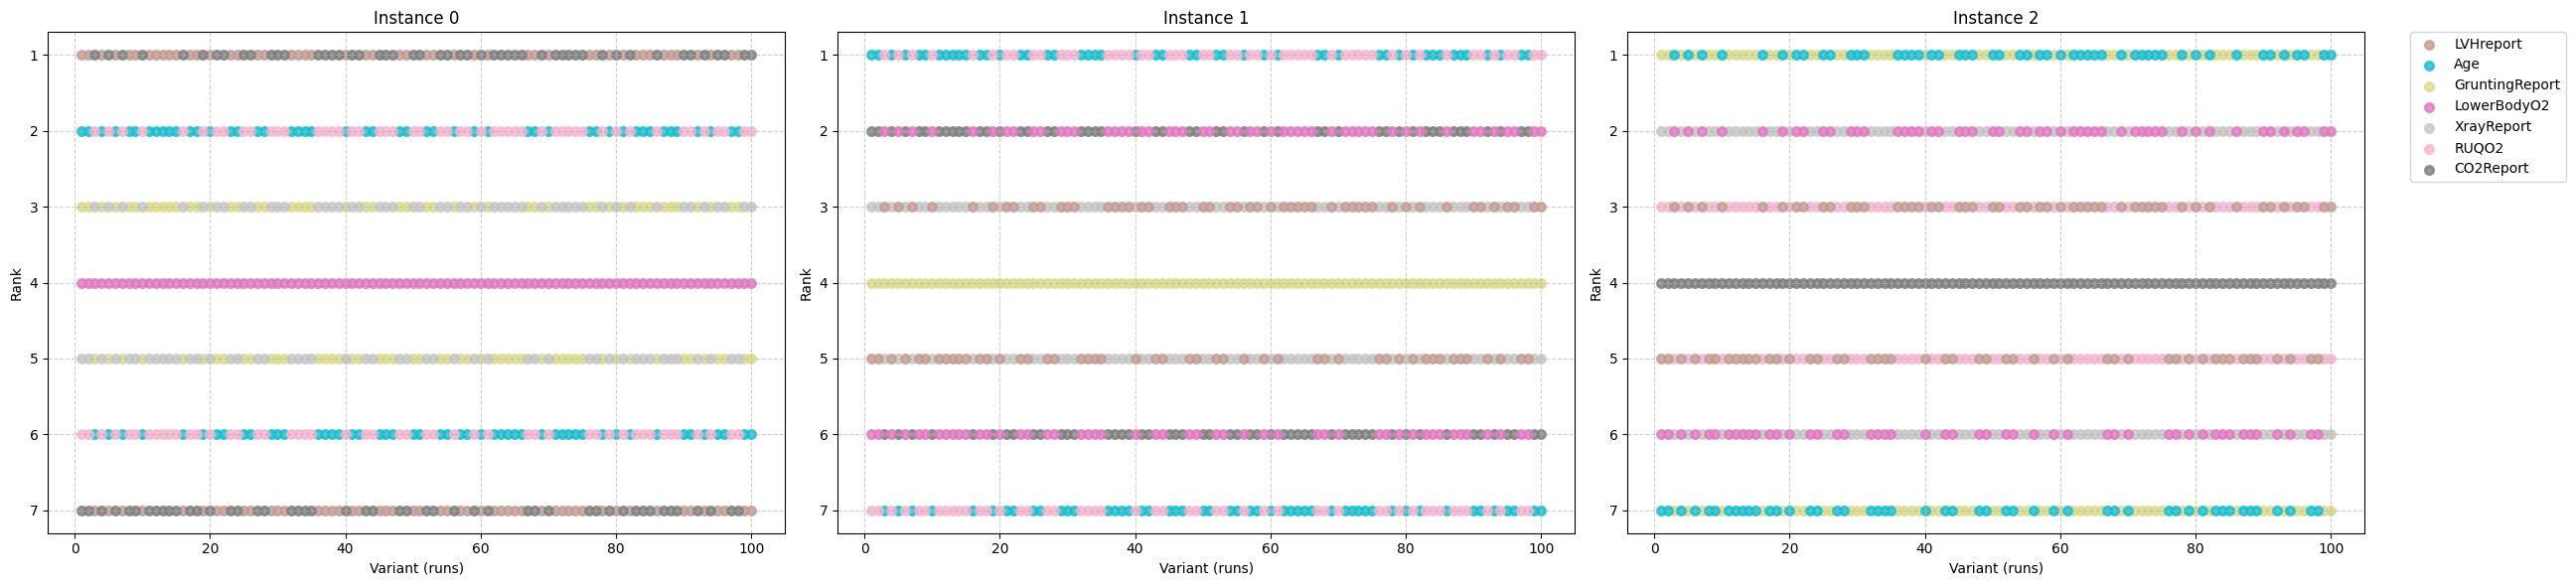

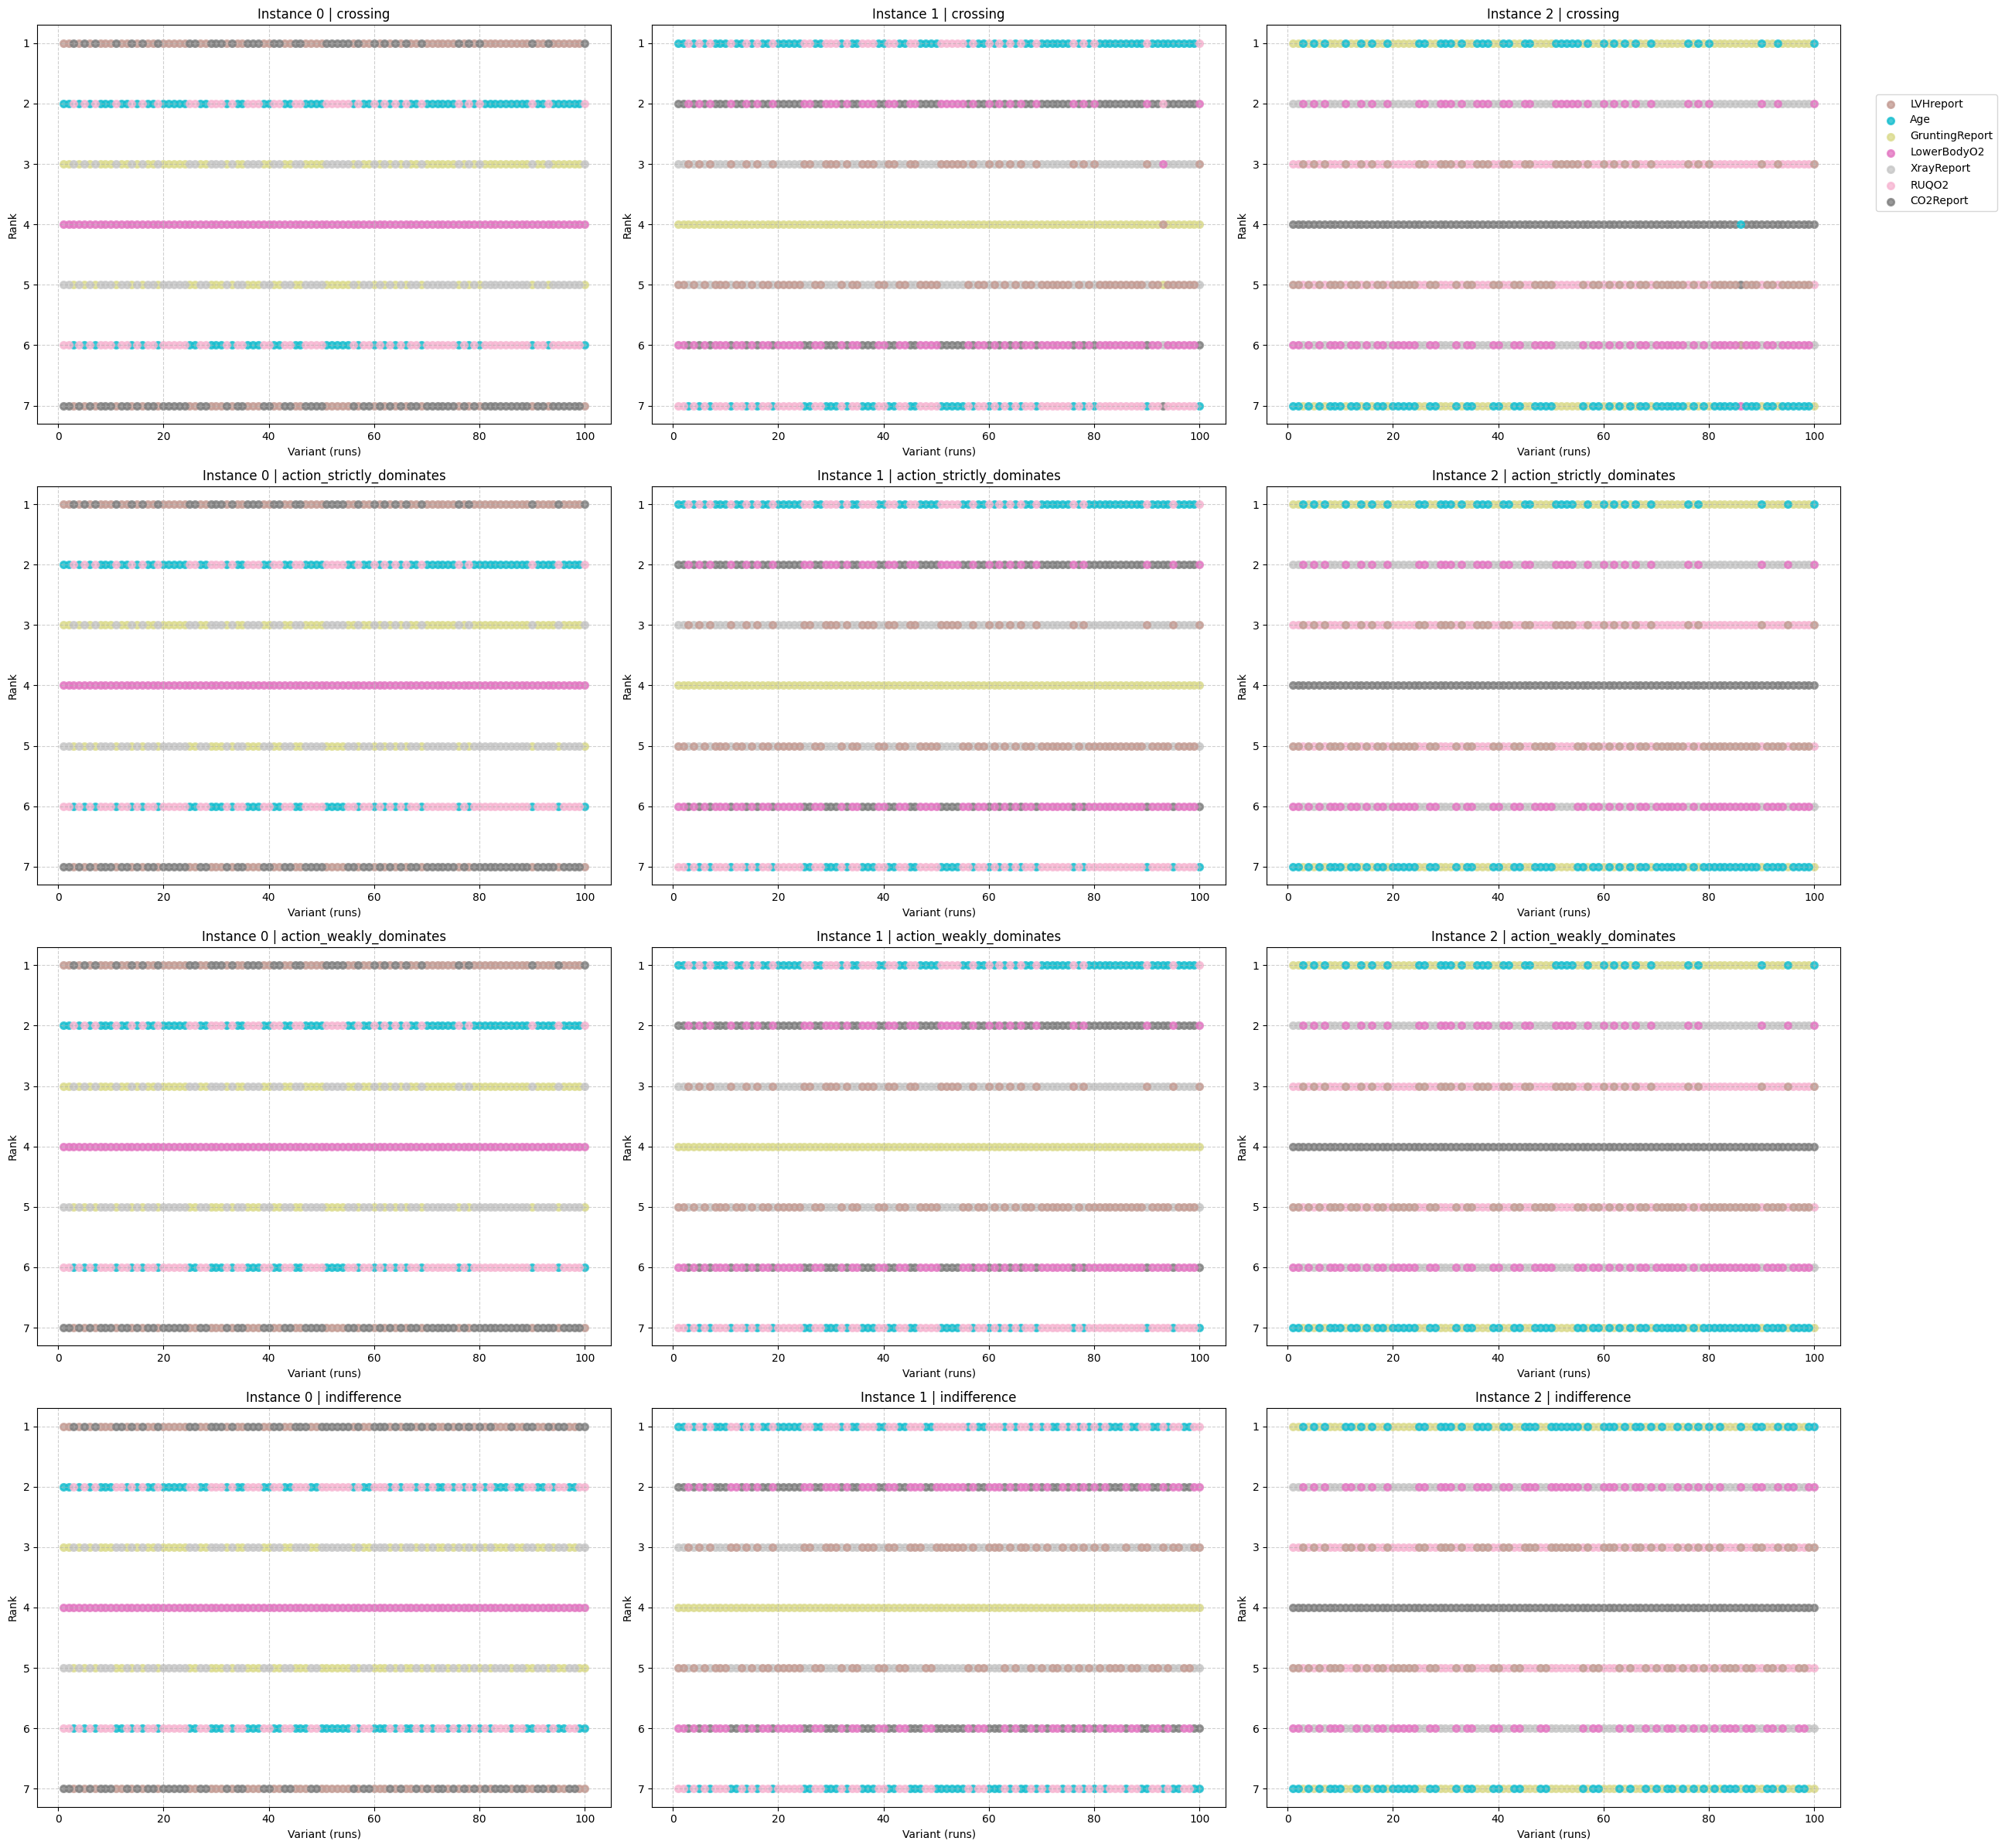

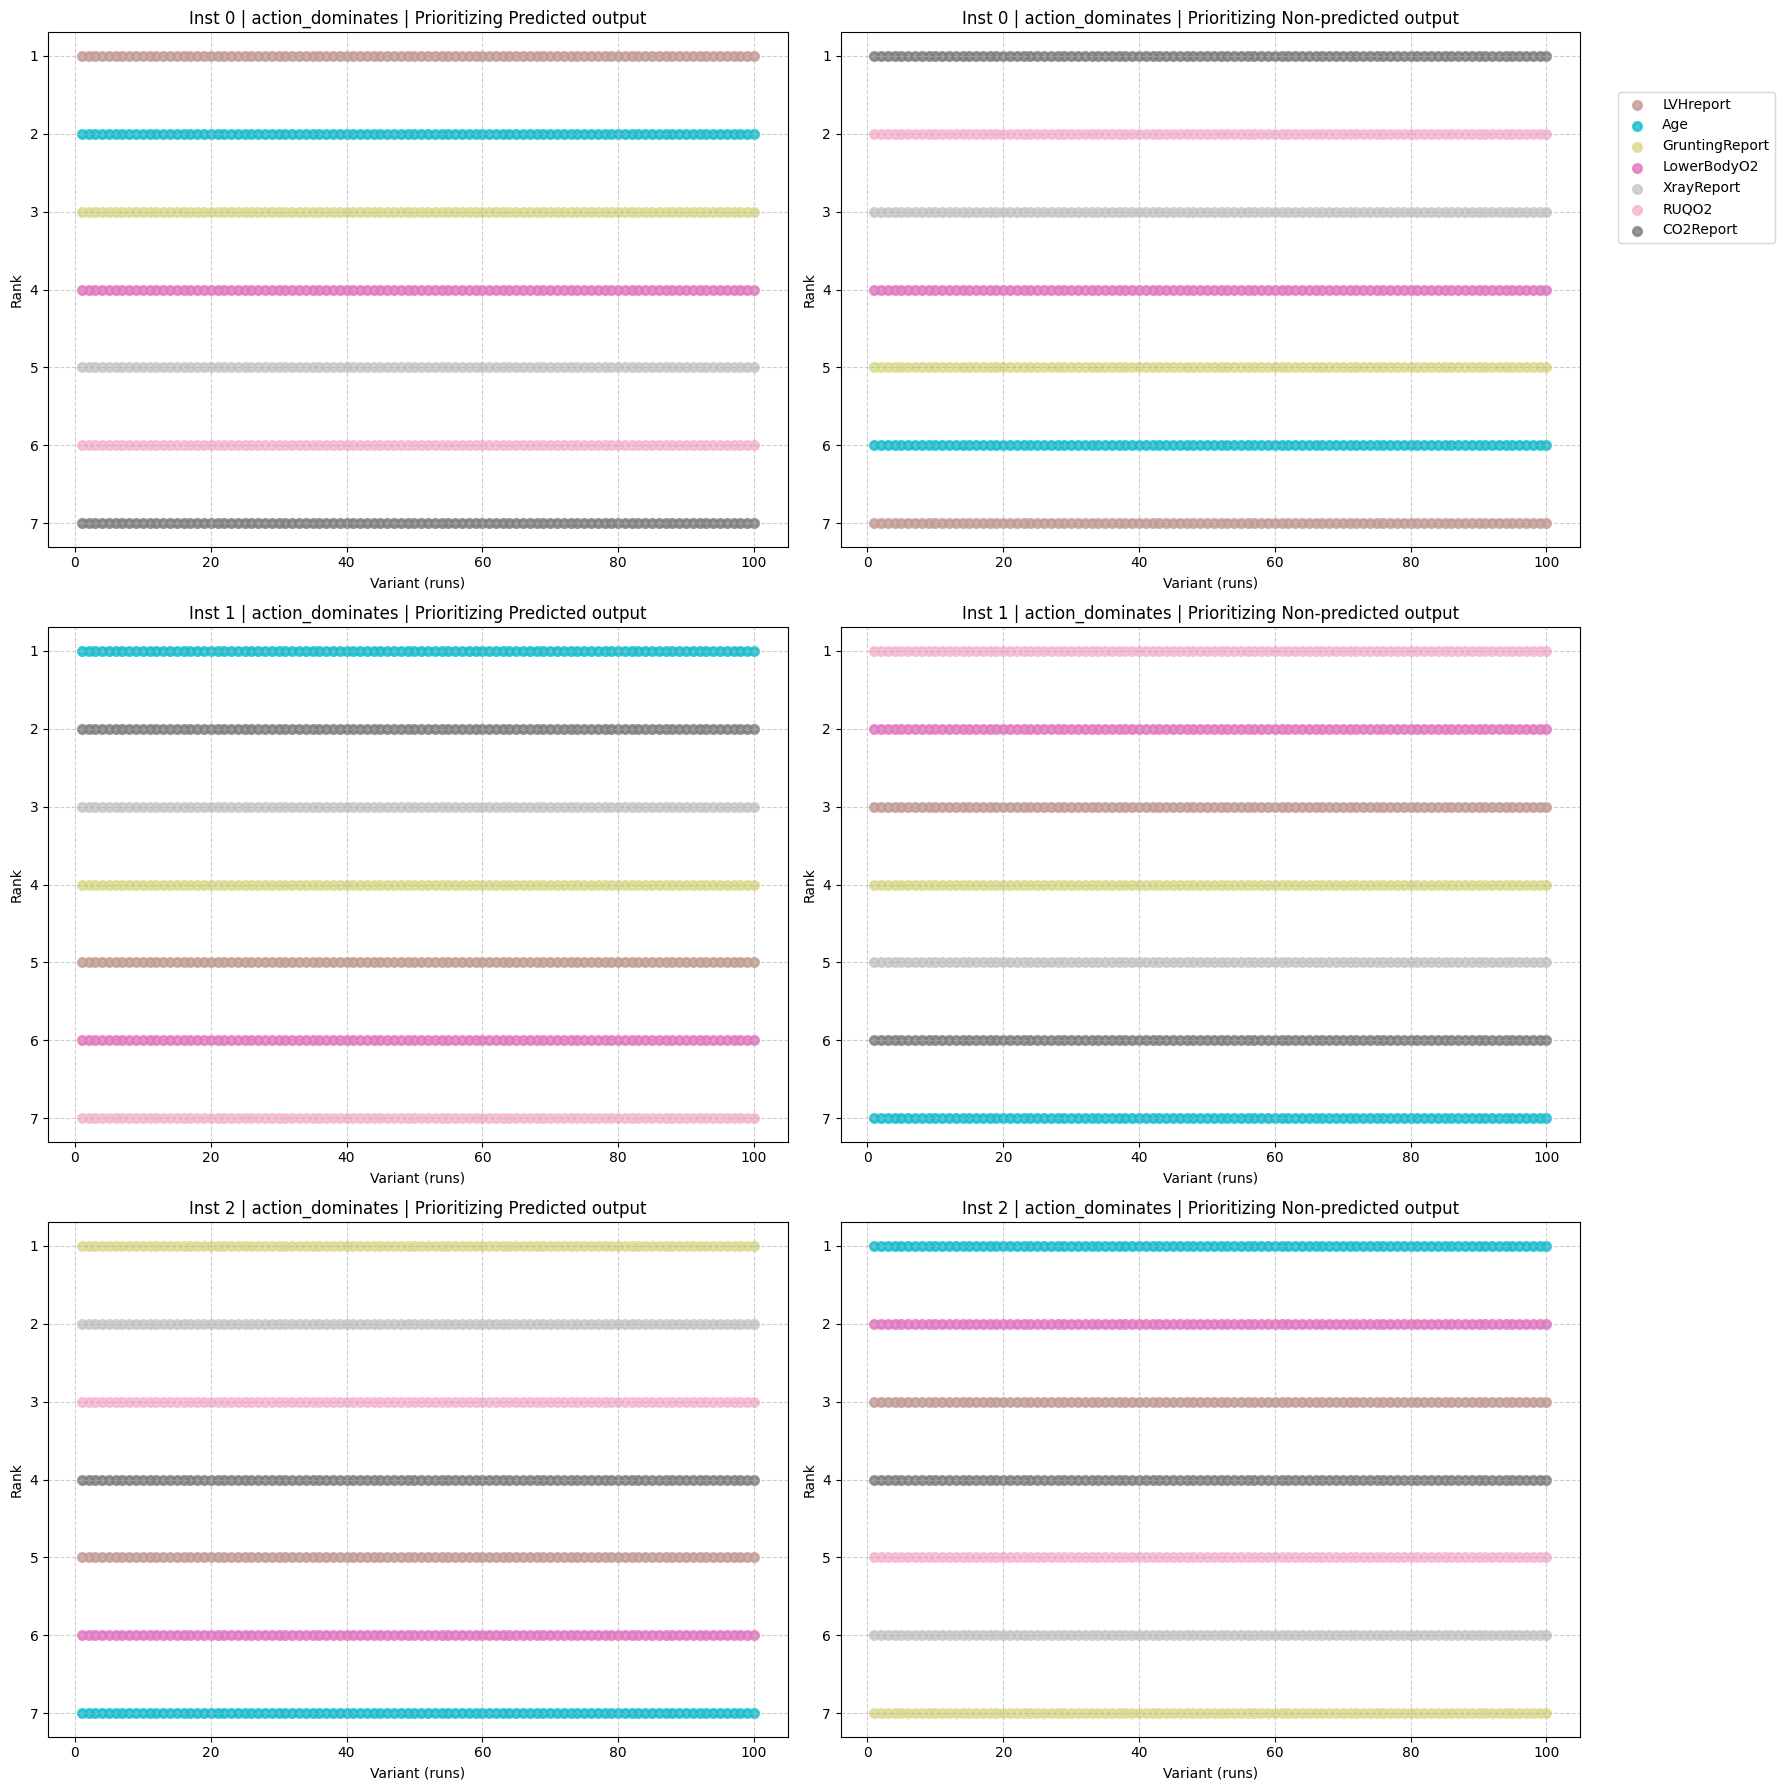

{'action_dominates': {0: {True: {'LVHreport': [1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1,
     1],
    'Age': [2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2

In [12]:
full_explainer_tester = ExplainerTester("Sensitivity", full_model, full_features, rq1_actions, rq1_causal, X_train_full)
x_instances_full = X_test_full.sample(n=3, random_state=RANDOM_SEED)
full_explainer_tester.test_explain_instance_phase_1(x_instances_full, display=True)
full_explainer_tester.test_explain_instance_phase_2(x_instances_full, category=["crossing", "action_strictly_dominates", "action_weakly_dominates", "indifference"], display=True)
full_explainer_tester.test_explain_instance_phase_3(x_instances_full, category="action_dominates", display=True)

## Comparison between baselines

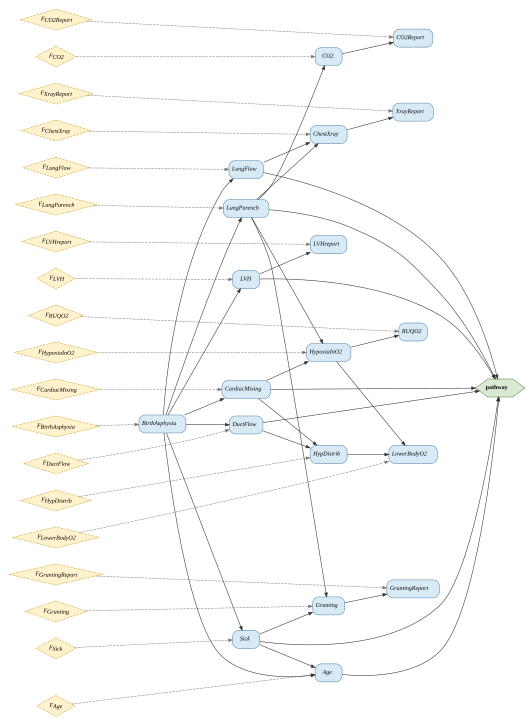

In [13]:
rq2_actions = [
    "pathway"
]

rq2_causal = CausalDAG(features=full_features, actions=rq2_actions)

rq2_causal.add_causal_edge("BirthAsphyxia", "Age")
rq2_causal.add_causal_edge("BirthAsphyxia", "Sick")
rq2_causal.add_causal_edge("BirthAsphyxia", "DuctFlow")
rq2_causal.add_causal_edge("BirthAsphyxia", "CardiacMixing")
rq2_causal.add_causal_edge("BirthAsphyxia", "LungParench")
rq2_causal.add_causal_edge("BirthAsphyxia", "LungFlow")
rq2_causal.add_causal_edge("BirthAsphyxia", "LVH")

rq2_causal.add_causal_edge("Sick", "Age")
rq2_causal.add_causal_edge("Sick", "Grunting")
rq2_causal.add_causal_edge("Sick", "pathway")

rq2_causal.add_causal_edge("DuctFlow", "HypDistrib")
rq2_causal.add_causal_edge("DuctFlow", "pathway")

rq2_causal.add_causal_edge("CardiacMixing", "HypDistrib")
rq2_causal.add_causal_edge("CardiacMixing", "HypoxiaInO2")
rq2_causal.add_causal_edge("CardiacMixing", "pathway")

rq2_causal.add_causal_edge("LungParench", "Grunting")
rq2_causal.add_causal_edge("LungParench", "HypoxiaInO2")
rq2_causal.add_causal_edge("LungParench", "CO2")
rq2_causal.add_causal_edge("LungParench", "ChestXray")
rq2_causal.add_causal_edge("LungParench", "pathway")

rq2_causal.add_causal_edge("LungFlow", "ChestXray")
rq2_causal.add_causal_edge("LungFlow", "pathway")

rq2_causal.add_causal_edge("LVH", "LVHreport")
rq2_causal.add_causal_edge("LVH", "pathway")

rq2_causal.add_causal_edge("Age", "pathway")

rq2_causal.add_causal_edge("Grunting", "GruntingReport")

rq2_causal.add_causal_edge("HypDistrib", "LowerBodyO2")

rq2_causal.add_causal_edge("HypoxiaInO2", "LowerBodyO2")
rq2_causal.add_causal_edge("HypoxiaInO2", "RUQO2")

rq2_causal.add_causal_edge("CO2", "CO2Report")

rq2_causal.add_causal_edge("ChestXray", "XrayReport")

rq2_causal.add_causal_edge("LVH", "LVHreport")

rq2_dot = rq2_causal.toDot()
rq2_graph = graphviz.Source(rq2_dot)
display(rq2_graph)

## Sensitivity over feature-action dependency relation